# Practice 3: Customer Clustering - Bước 4: Khám phá dữ liệu (Exploratory Data Analysis - EDA)

---

## 1. Import các thư viện và tải dữ liệu đã làm sạch

Chúng ta sẽ đọc tệp `Train_cleaned.csv` từ thư mục `../data/processed/` được tạo từ Bước 3.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cấu hình vẽ đồ thị
%matplotlib inline
sns.set_theme(style="whitegrid")

# Load dữ liệu đã làm sạch
df = pd.read_csv("../data/processed/Train_cleaned.csv")
print(f"Kích thước dữ liệu sạch: {df.shape}")
df.head(20)

Kích thước dữ liệu sạch: (8068, 11)


,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,1.0,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,1.0,High,6.0,Cat_6,A
5,461319,Male,Yes,56,No,Artist,0.0,Average,2.0,Cat_6,C
6,460156,Male,No,32,Yes,Healthcare,1.0,Low,3.0,Cat_6,C
7,464347,Female,No,33,Yes,Healthcare,1.0,Low,3.0,Cat_6,D
8,465015,Female,Yes,61,Yes,Engineer,0.0,Low,3.0,Cat_7,D
9,465176,Female,Yes,55,Yes,Artist,1.0,Average,4.0,Cat_6,C


## 2. Phân tích trực quan hóa biến số học (Numerical Features)

Các thuộc tính kiểu số gồm: `Age`, `Work_Experience`, `Family_Size`.

### 2.1. Phân phối và Boxplot của các biến số học

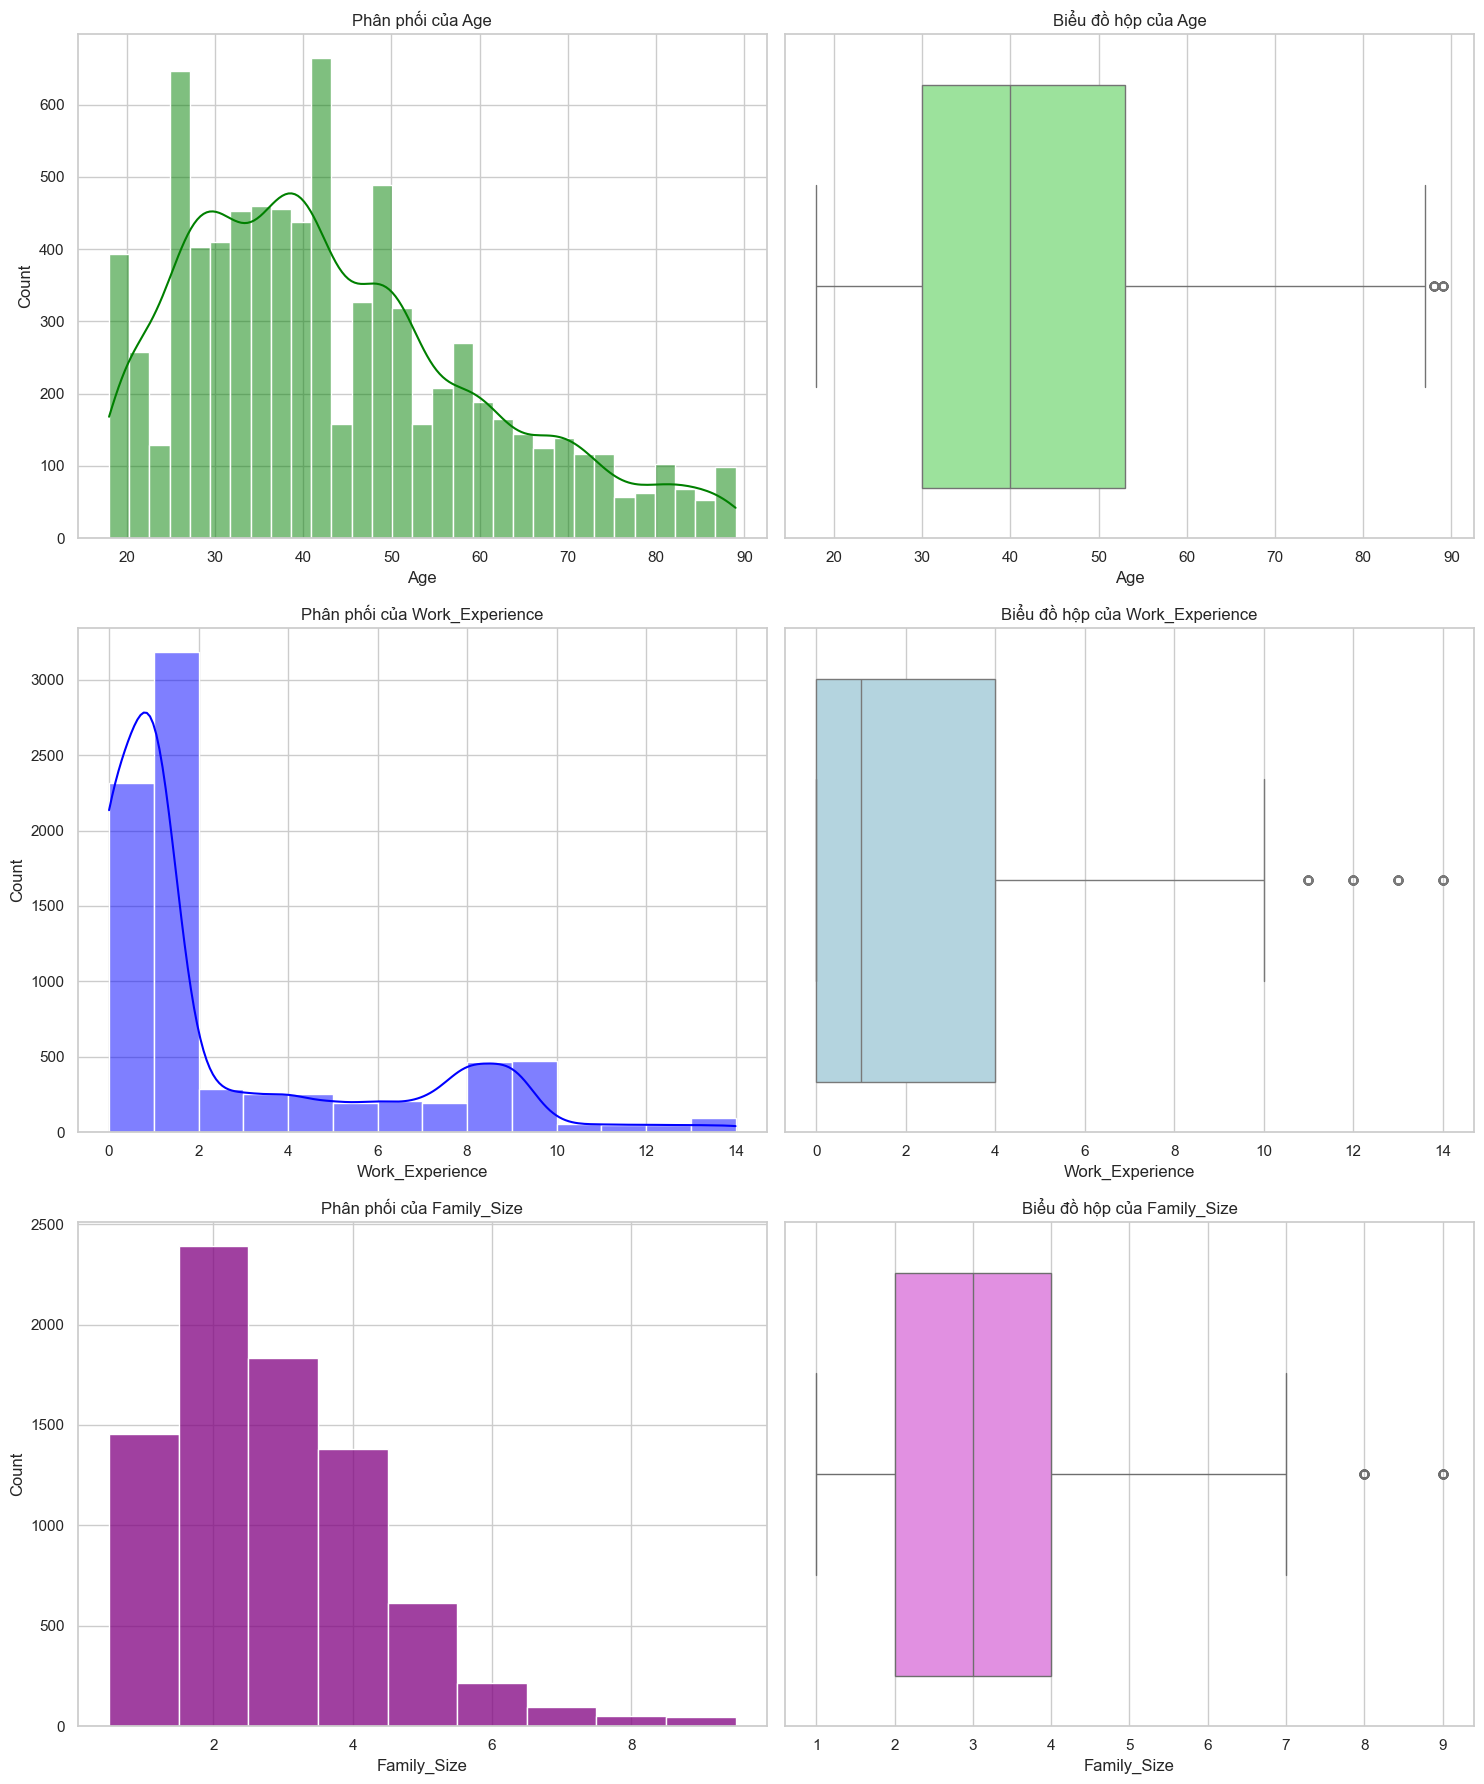

In [2]:
fig, axes = plt.subplots(3, 2, figsize=(15, 18))

# Age
sns.histplot(data=df, x='Age', kde=True, ax=axes[0, 0], color='green')
axes[0, 0].set_title("Phân phối của Age")
sns.boxplot(data=df, x='Age', ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title("Biểu đồ hộp của Age")

# Work_Experience
sns.histplot(data=df, x='Work_Experience', kde=True, ax=axes[1, 0], color='blue', binwidth=1)
axes[1, 0].set_title("Phân phối của Work_Experience")
sns.boxplot(data=df, x='Work_Experience', ax=axes[1, 1], color='lightblue')
axes[1, 1].set_title("Biểu đồ hộp của Work_Experience")

# Family_Size
sns.histplot(data=df, x='Family_Size', kde=False, discrete=True, ax=axes[2, 0], color='purple')
axes[2, 0].set_title("Phân phối của Family_Size")
sns.boxplot(data=df, x='Family_Size', ax=axes[2, 1], color='violet')
axes[2, 1].set_title("Biểu đồ hộp của Family_Size")

plt.tight_layout()
plt.show()

### 2.2. Ma trận tương quan của các biến số học (Numerical Correlation Heatmap)

Chúng ta tính toán hệ số tương quan Pearson giữa 3 đặc trưng số học này xem chúng có quan hệ tuyến tính nào đáng kể hay không.

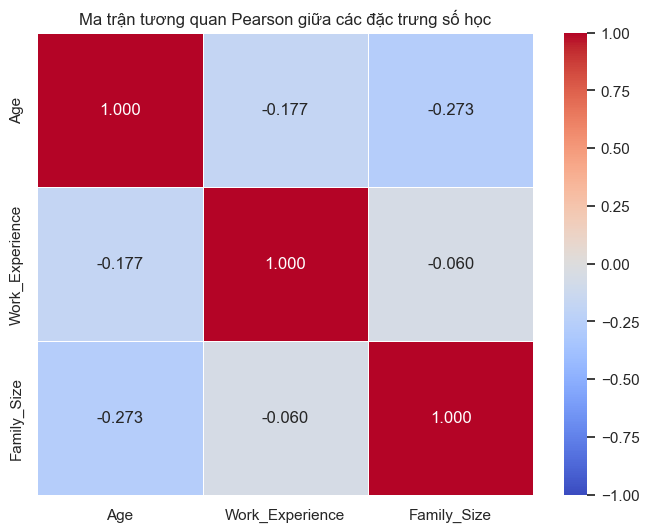

In [3]:
plt.figure(figsize=(8, 6))
corr_matrix = df[['Age', 'Work_Experience', 'Family_Size']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Ma trận tương quan Pearson giữa các đặc trưng số học")
plt.show()

#### Nhận xét toán học:
- `Age` và `Family_Size` có tương quan nghịch nhẹ (khoảng $-0.28$). Điều này hợp lý trên thực tế: những người lớn tuổi thường có gia đình nhỏ hơn (con cái đã trưởng thành ra ở riêng), trong khi những người trẻ tuổi thường sống chung với gia đình đông người hơn.
- Tương quan giữa `Work_Experience` và `Age` rất thấp (gần $-0.19$). Điểm này khá thú vị, vì tuổi tác tăng không đồng nghĩa với số năm kinh nghiệm tăng trong tập dữ liệu này (có thể do chuyển đổi nghề nghiệp hoặc phân loại nghề nghiệp đặc thù).
- Nhìn chung, không có hiện tượng đa cộng tuyến (multicollinearity) mạnh giữa các biến số học này (tất cả đều $< 0.3$), do đó chúng ta nên giữ lại cả 3 biến số học.

## 3. Phân tích trực quan hóa biến phân loại (Categorical Features)

Các cột phân loại gồm: `Gender`, `Ever_Married`, `Graduated`, `Profession`, `Spending_Score`, `Var_1`.

/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_96771/666059815.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index, palette='Set2')
/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_96771/666059815.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index, palette='Set2')
/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_96771/666059815.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(

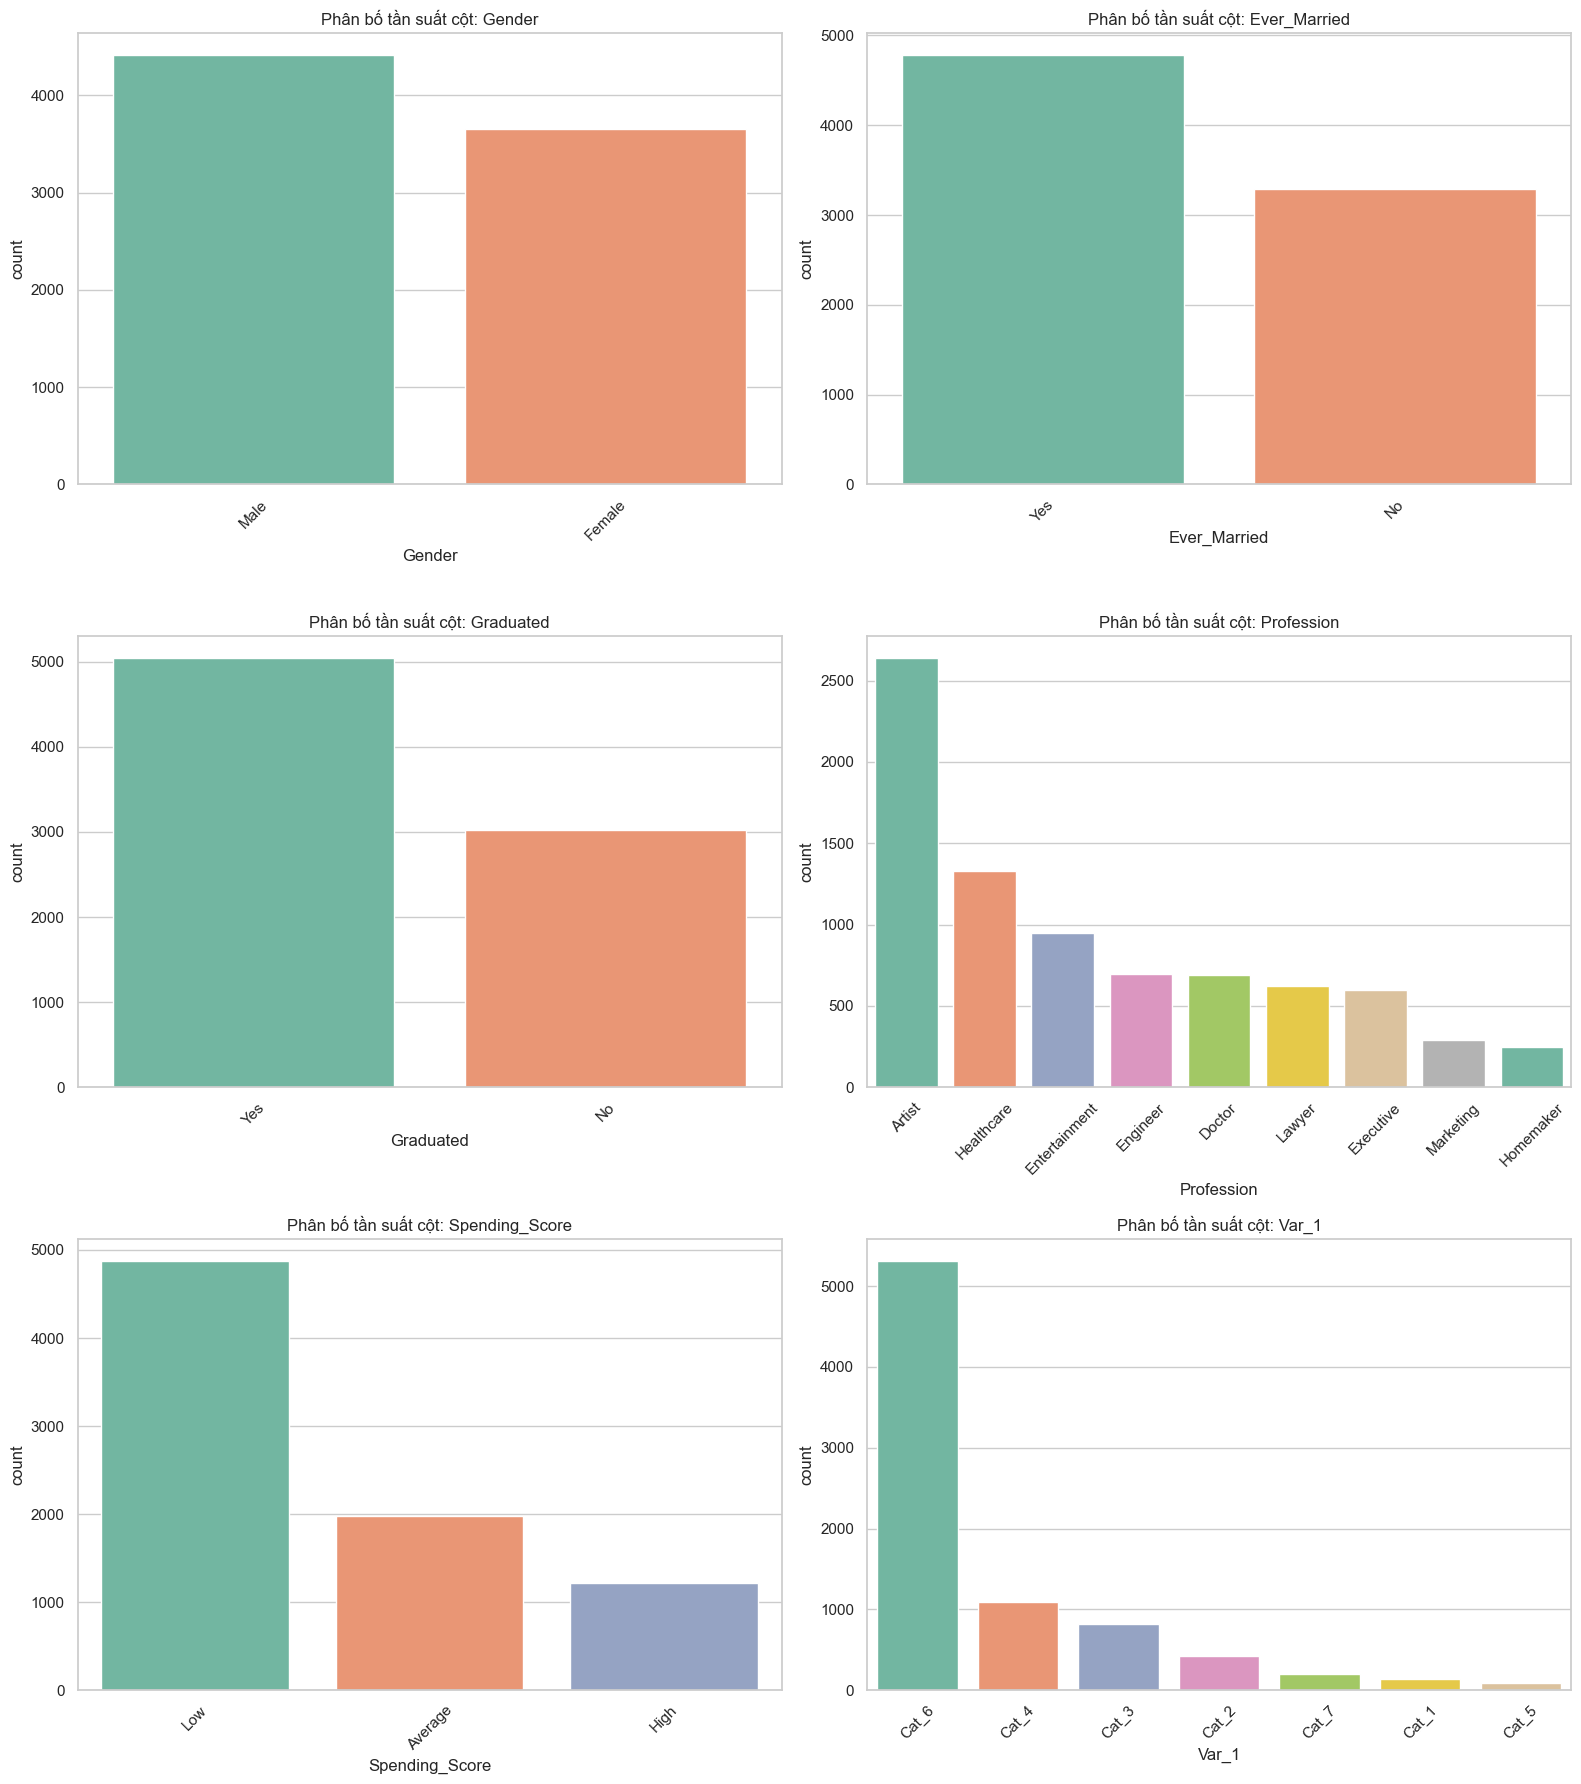

In [4]:
cat_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score', 'Var_1']

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index, palette='Set2')
    axes[i].set_title(f"Phân bố tần suất cột: {col}")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Kiểm định liên kết phi giám sát (Chi-Square Independence Test Suite)

Như đã thảo luận ở Bước 3, biến phân loại ẩn danh `Var_1` cần được đánh giá xem có chứa thông tin hữu ích hay hoàn toàn trùng lặp/độc lập với các đặc trưng đầu vào khác.

Chúng ta tiến hành thực hiện kiểm định Chi-bình phương độc lập thống kê giữa **`Var_1`** và **tất cả** các đặc trưng phân loại đầu vào khác để đánh giá mối quan hệ tương quan của nó.

In [5]:
other_cat_cols = ['Gender', 'Ever_Married', 'Graduated', 'Profession', 'Spending_Score']

print("=== KẾT QUẢ KIỂM ĐỊNH CHI-SQUARE VỚI BIẾN Var_1 ===\n")
for col in other_cat_cols:
    contingency_table = pd.crosstab(df['Var_1'], df[col])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency_table)
    print(f"Kiểm định giữa Var_1 và {col}:")
    print(f"  - Chi-square statistic: {chi2:.4f}")
    print(f"  - p-value: {p_val:.2e}")
    if p_val < 0.05:
        print(f"  -> KẾT LUẬN: Bác bỏ H0, hai biến PHỤ THUỘC THỐNG KÊ (p < 0.05).")
    else:
        print(f"  -> KẾT LUẬN: Chấp nhận H0, hai biến ĐỘC LẬP THỐNG KÊ (p >= 0.05).")
    print("-" * 50)

=== KẾT QUẢ KIỂM ĐỊNH CHI-SQUARE VỚI BIẾN Var_1 ===

Kiểm định giữa Var_1 và Gender:
  - Chi-square statistic: 19.2238
  - p-value: 3.80e-03
  -> KẾT LUẬN: Bác bỏ H0, hai biến PHỤ THUỘC THỐNG KÊ (p < 0.05).
--------------------------------------------------
Kiểm định giữa Var_1 và Ever_Married:
  - Chi-square statistic: 76.8970
  - p-value: 1.56e-14
  -> KẾT LUẬN: Bác bỏ H0, hai biến PHỤ THUỘC THỐNG KÊ (p < 0.05).
--------------------------------------------------
Kiểm định giữa Var_1 và Graduated:
  - Chi-square statistic: 373.6514
  - p-value: 1.29e-77
  -> KẾT LUẬN: Bác bỏ H0, hai biến PHỤ THUỘC THỐNG KÊ (p < 0.05).
--------------------------------------------------
Kiểm định giữa Var_1 và Profession:
  - Chi-square statistic: 555.9995
  - p-value: 1.27e-87
  -> KẾT LUẬN: Bác bỏ H0, hai biến PHỤ THUỘC THỐNG KÊ (p < 0.05).
--------------------------------------------------
Kiểm định giữa Var_1 và Spending_Score:
  - Chi-square statistic: 87.8513
  - p-value: 1.28e-13
  -> KẾT LUẬN: B

## 5. Khảo sát mối quan hệ đa biến (Multivariate Analysis)

Để khám phá các hành vi tiêu dùng ẩn phục vụ cho việc hình dung các phân khúc khách hàng, chúng ta trực quan hóa mối quan hệ chéo giữa một số đặc trưng quan trọng.

### 5.1. Mối quan hệ giữa Độ tuổi (Age) và Mức độ chi tiêu (Spending Score)

/var/folders/5n/q_dvq0yj0p74ffh__0vftbfm0000gn/T/ipykernel_96771/2234200169.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Spending_Score', y='Age', order=['Low', 'Average', 'High'], palette='muted')


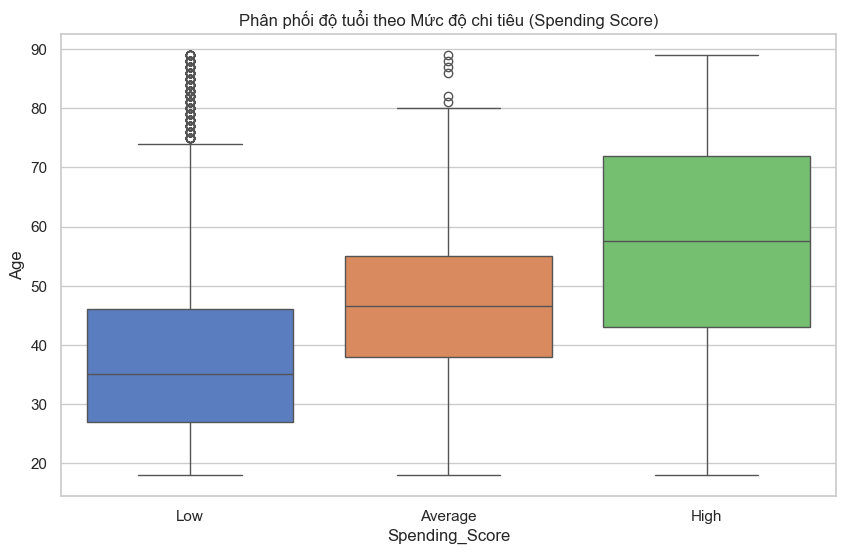

In [6]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Spending_Score', y='Age', order=['Low', 'Average', 'High'], palette='muted')
plt.title("Phân phối độ tuổi theo Mức độ chi tiêu (Spending Score)")
plt.show()

### 5.2. Mối quan hệ giữa Nghề nghiệp (Profession) và Mức độ chi tiêu (Spending Score)

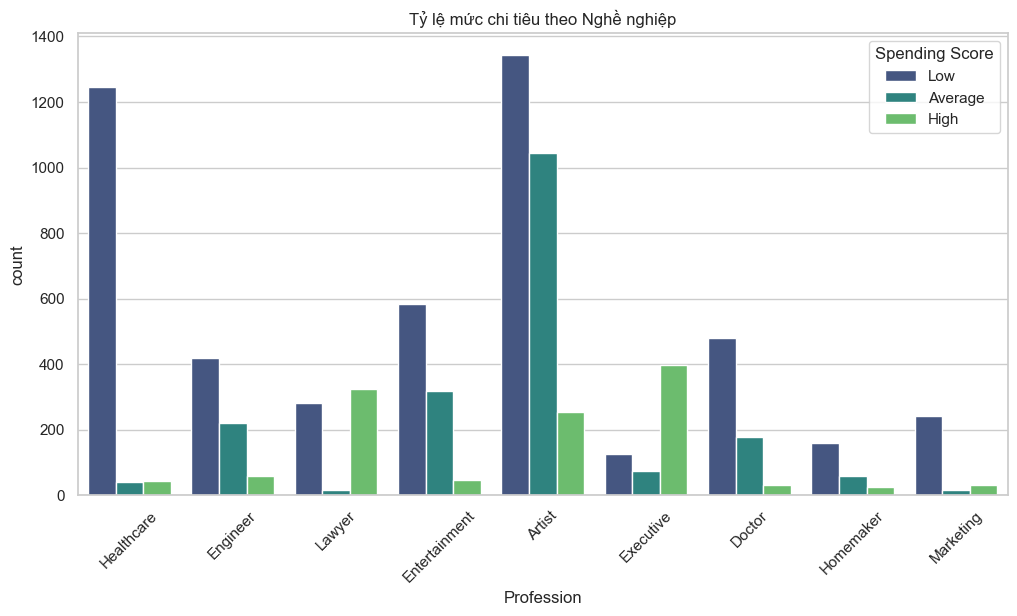

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Profession', hue='Spending_Score', hue_order=['Low', 'Average', 'High'], palette='viridis')
plt.title("Tỷ lệ mức chi tiêu theo Nghề nghiệp")
plt.xticks(rotation=45)
plt.legend(title='Spending Score')
plt.show()

## 6. Tổng hợp các phát hiện quan trọng (Key Insights)

Hãy tổng kết các insight rút ra được từ các bước phân tích trên để chuẩn bị cho bước Feature Engineering và giải thích cụm sau này:

1. **Mối quan hệ giữa Độ tuổi và Chi tiêu**: Khách hàng trẻ tuổi (trung vị ~28 tuổi) chủ yếu có mức chi tiêu **Low** (Thấp). Khách hàng trung niên và lớn tuổi (trung vị >50 tuổi) có mức chi tiêu cao hơn hẳn (**Average** và **High**).
2. **Tầm quan trọng của Nghề nghiệp**: Nhóm ngành nghề có mức chi tiêu cao nổi bật là *Artist* (Nghệ sĩ - chiếm số lượng cực đông), *Executive* (Giám đốc) và *Lawyer* (Luật sư). Ngược lại, nhóm *Healthcare* (Y tế) chủ yếu là các bác sĩ/nhân viên y tế trẻ tuổi với mức chi tiêu rất thấp.
3. **Tình trạng của biến ẩn danh `Var_1`**:
   - Từ kết quả chạy của bạn đối với phần kiểm định độc lập thống kê Chi-Square ở Mục 4, bạn có phát hiện mối quan hệ phụ thuộc thống kê nào của `Var_1` với các biến khác hay không?
   - Dựa trên các giá trị p-value đó, hãy thảo luận xem chúng ta có giữ lại biến này hay loại bỏ?